# 5. Exploratory Data Analysis (EDA)

L'EDA (Exploratory Data Analysis) consiste à explorer et analyser les données nettoyées afin de mieux comprendre leur distribution, détecter les valeurs inhabituelles et identifier les relations entre les variables et le temps de livraison.

Nous allons utiliser des statistiques, des regroupements et des visualisations pour découvrir les principaux patterns du dataset.

### 5.1 Vue générale du dataset

Nous commençons par examiner la structure générale du dataset après le nettoyage.

Cette étape permet de vérifier le nombre de lignes et de colonnes, les types des variables et les principales statistiques numériques.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
clean_df = pd.read_csv('../data/cleaned_data.csv')
clean_df.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Type_of_vehicle,Road_traffic_density,multiple_deliveries,Time_taken(min),distance,order_hour,pickup_hour
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,motorcycle,High,0.0,24,3.020737,11.0,11
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,scooter,Jam,1.0,33,20.143737,19.0,19
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,motorcycle,Low,1.0,26,1.549693,8.0,8
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,motorcycle,Medium,1.0,21,7.774497,18.0,18
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,scooter,High,1.0,30,6.197898,13.0,13


In [33]:
clean_df.shape


(41522, 15)

In [4]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,41522.0,29.568807,5.655790,20.000000,25.000000,30.000000,34.000000,39.000000
Delivery_person_Ratings,41522.0,4.634261,0.321795,1.000000,4.500000,4.700000,4.800000,5.000000
Restaurant_latitude,41522.0,18.896960,5.461033,9.957144,12.986047,19.060834,22.751234,30.914057
Restaurant_longitude,41522.0,76.914307,3.493224,72.768726,73.897902,76.618203,78.368855,88.433452
Delivery_location_latitude,41522.0,18.960623,5.462841,9.967144,13.065662,19.115838,22.818060,31.054057
Delivery_location_longitude,41522.0,76.977970,3.493405,72.778726,73.939315,76.663067,78.403391,88.563452
multiple_deliveries,41522.0,0.750710,0.567383,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken(min),41522.0,26.315447,9.380634,10.000000,19.000000,26.000000,32.000000,54.000000
distance,41522.0,9.704133,5.593935,1.463837,4.648474,9.177295,13.659637,20.942906
order_hour,41522.0,17.471051,4.746506,0.000000,15.000000,19.000000,21.000000,23.000000


In [5]:
clean_df.duplicated().sum()

np.int64(0)

In [6]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41522 entries, 0 to 41521
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41522 non-null  float64
 1   Delivery_person_Ratings      41522 non-null  float64
 2   Restaurant_latitude          41522 non-null  float64
 3   Restaurant_longitude         41522 non-null  float64
 4   Delivery_location_latitude   41522 non-null  float64
 5   Delivery_location_longitude  41522 non-null  float64
 6   Order_Date                   41522 non-null  str    
 7   Weatherconditions            41522 non-null  str    
 8   Road_traffic_density         41522 non-null  str    
 9   Type_of_vehicle              41522 non-null  str    
 10  multiple_deliveries          41522 non-null  float64
 11  Time_taken(min)              41522 non-null  int64  
 12  distance                     41522 non-null  float64
 13  order_hour                 

### 5.2 Analyse de la variable cible

La variable cible de notre projet est `Time_taken(min)`, qui représente le temps total nécessaire pour effectuer une livraison.

Nous allons analyser sa distribution et ses statistiques afin de mieux comprendre les temps de livraison dans notre dataset.

In [4]:
clean_df["Time_taken(min)"].describe().T

count    41522.000000
mean        26.315447
std          9.380634
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

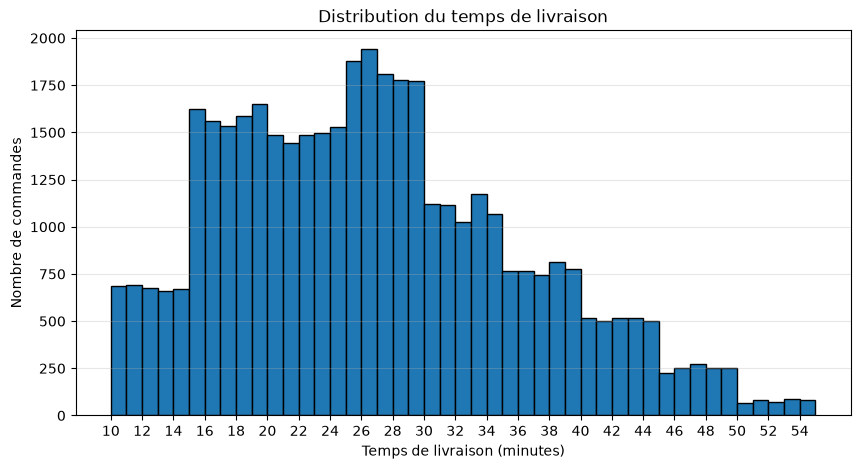

In [ ]:

plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Time_taken(min)"],
    bins=range(10, 56),
    edgecolor="black"
)

plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution du temps de livraison")
plt.xticks(range(10, 55, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3 Analyse des variables numériques

Nous allons maintenant analyser les principales variables numériques du dataset.

Cette étape permet d'observer leur distribution, leurs valeurs minimales et maximales, ainsi que d'identifier d'éventuelles valeurs inhabituelles.

In [5]:
numerical_cols = [
    "Delivery_person_Age",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "distance"
]

clean_df[numerical_cols].describe()

,Delivery_person_Age,multiple_deliveries,order_hour,pickup_hour,distance
count,41522.000000,41522.000000,41522.000000,41522.000000,41522.000000
mean,29.568807,0.750710,17.471051,17.145971,9.704133
std,5.655790,0.567383,4.746506,5.318611,5.593935
min,20.000000,0.000000,0.000000,0.000000,1.463837
25%,25.000000,0.000000,15.000000,14.000000,4.648474
50%,30.000000,1.000000,19.000000,19.000000,9.177295
75%,34.000000,1.000000,21.000000,21.000000,13.659637
max,39.000000,3.000000,23.000000,23.000000,20.942906


### 5.3.1 Distribution de l'âge des livreurs

Nous allons visualiser la distribution de l'âge des livreurs afin d'observer les âges les plus fréquents et la répartition générale de cette variable.

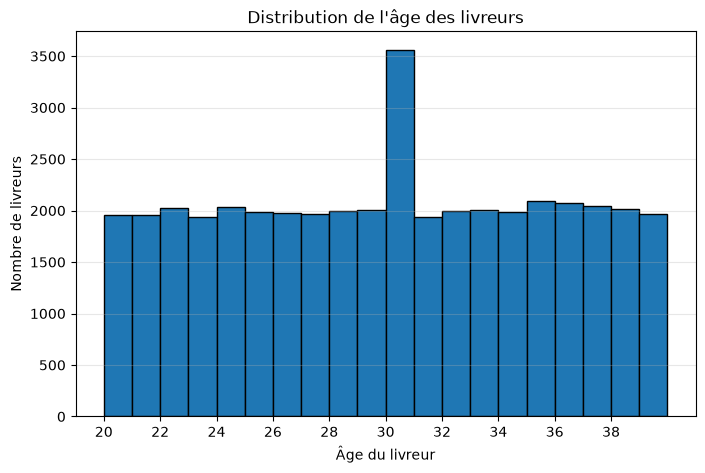

In [ ]:

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Delivery_person_Age"],
    bins=range(20, 41),
    edgecolor="black"
)

plt.xlabel("Âge du livreur")
plt.ylabel("Nombre de livreurs")
plt.title("Distribution de l'âge des livreurs")
plt.xticks(range(20, 40, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.2 Analyse des livraisons multiples

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons observer la fréquence de chaque valeur afin de comprendre leur répartition dans le dataset.

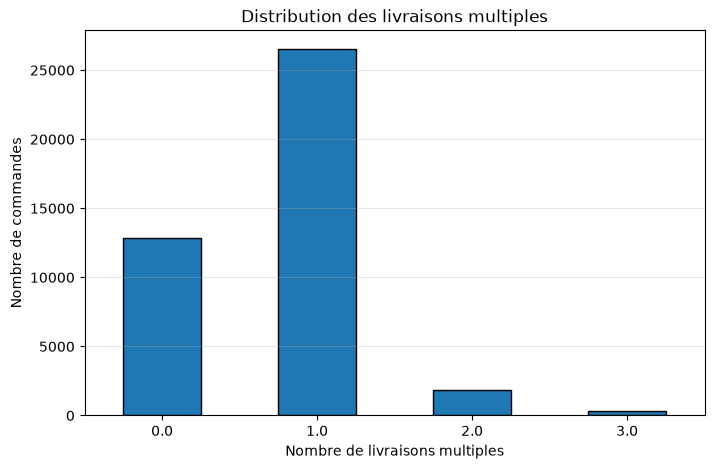

In [11]:
clean_df["multiple_deliveries"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Nombre de livraisons multiples")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des livraisons multiples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.3 Analyse de l'heure de commande

Nous allons analyser la répartition des commandes selon l'heure de la journée afin d'identifier les périodes où les commandes sont les plus fréquentes.

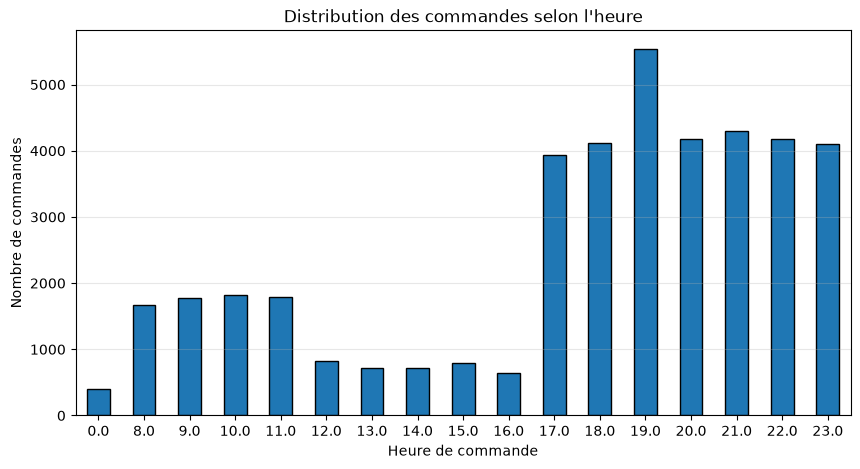

In [12]:
plt.figure(figsize=(10, 5))

clean_df["order_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de commande")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.4 Analyse de l'heure de récupération

Nous allons analyser la répartition des commandes selon l'heure de récupération afin d'identifier les périodes les plus fréquentes.

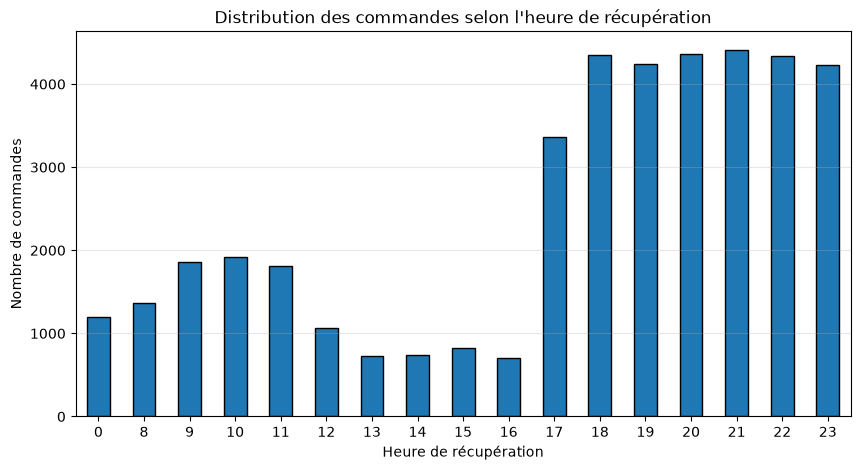

In [13]:
plt.figure(figsize=(10, 5))

clean_df["pickup_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de récupération")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure de récupération")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.5 Analyse de la distance de livraison

Nous allons analyser la distribution de la distance entre le restaurant et le lieu de livraison.

Cette analyse permet de comprendre les distances généralement parcourues et d'identifier d'éventuelles valeurs inhabituelles.

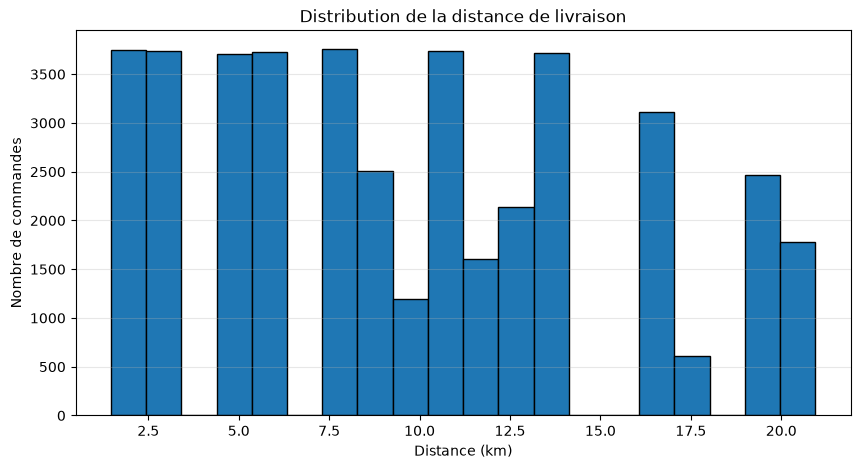

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["distance"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Distance (km)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution de la distance de livraison")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.4 Analyse des variables catégorielles

Nous allons maintenant analyser les variables catégorielles du dataset.

L'objectif est d'observer la fréquence de chaque catégorie et d'identifier les catégories les plus représentées dans les données.

Pour cette analyse, nous utiliserons des diagrammes en barres, adaptés à la comparaison de catégories.

In [15]:
clean_df["Weatherconditions"].value_counts()

Weatherconditions
Fog           7382
Stormy        6932
Cloudy        6881
Sandstorms    6853
Windy         6792
Sunny         6682
Name: count, dtype: int64

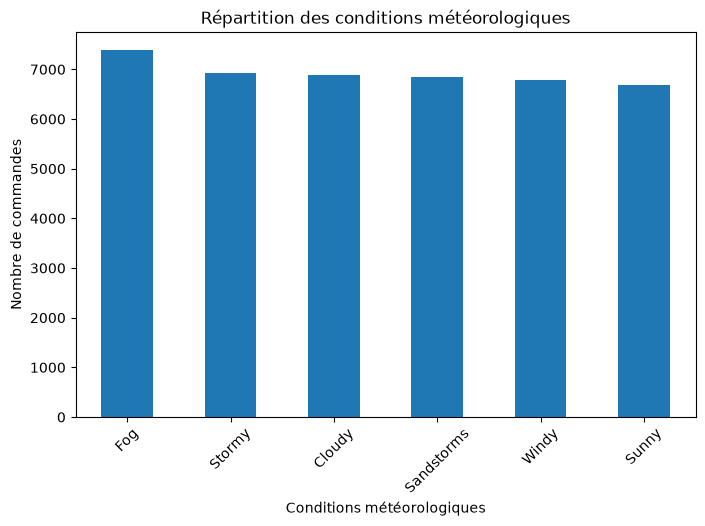

In [16]:

clean_df["Weatherconditions"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Conditions météorologiques")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des conditions météorologiques")
plt.xticks(rotation=45)
plt.show()

In [17]:
clean_df["Type_of_vehicle"].value_counts()

Type_of_vehicle
motorcycle           24197
scooter              13878
electric_scooter      3404
bicycle                 43
Name: count, dtype: int64

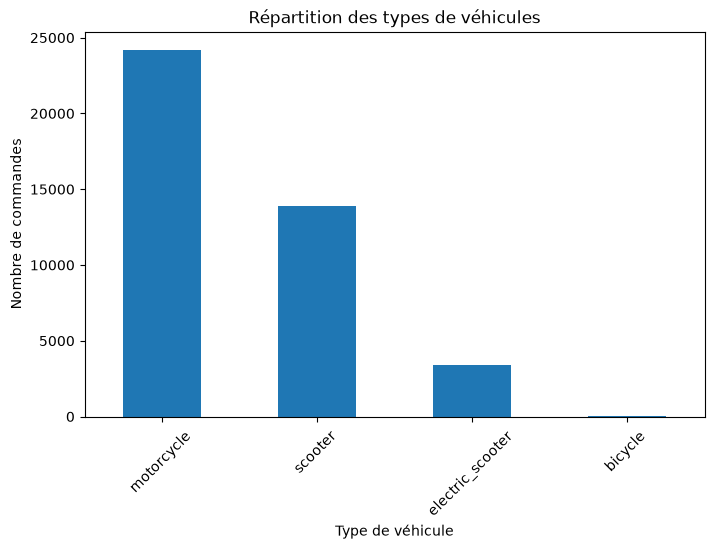

In [18]:
clean_df["Type_of_vehicle"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Type de véhicule")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des types de véhicules")
plt.xticks(rotation=45)
plt.show()

In [19]:
clean_df["Road_traffic_density"].value_counts()

Road_traffic_density
Low        14095
Jam        12950
Medium     10023
High        4046
Unknown      408
Name: count, dtype: int64

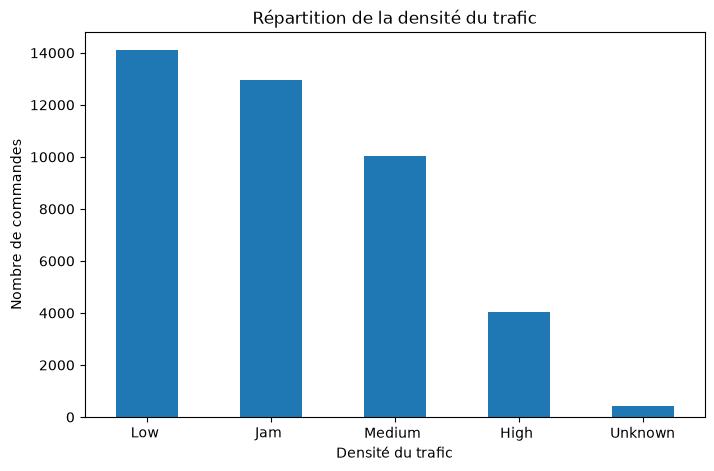

In [20]:
clean_df["Road_traffic_density"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Densité du trafic")
plt.ylabel("Nombre de commandes")
plt.title("Répartition de la densité du trafic")
plt.xticks(rotation=0)
plt.show()

In [21]:
clean_df["Road_traffic_density"].unique()

<ArrowStringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'Unknown']
Length: 5, dtype: str

In [22]:
clean_df["Road_traffic_density"].isna().sum()

np.int64(0)

In [23]:
clean_df["Road_traffic_density"] = (
    clean_df["Road_traffic_density"].str.strip()
)

In [24]:
clean_df["Road_traffic_density"].value_counts()

Road_traffic_density
Low        14095
Jam        12950
Medium     10023
High        4046
Unknown      408
Name: count, dtype: int64

In [25]:
clean_df["Road_traffic_density"] = (
    clean_df["Road_traffic_density"].replace(
        "Unknown",
        clean_df["Road_traffic_density"].mode()[0]
    )
)

clean_df["Road_traffic_density"].value_counts()


Road_traffic_density
Low       14503
Jam       12950
Medium    10023
High       4046
Name: count, dtype: int64

###  Analyse du type de véhicule

Nous allons analyser la variable `Type_of_vehicle` afin d'observer la répartition des différents types de véhicules utilisés pour les livraisons.

In [26]:
clean_df["Type_of_vehicle"].value_counts()

Type_of_vehicle
motorcycle           24197
scooter              13878
electric_scooter      3404
bicycle                 43
Name: count, dtype: int64

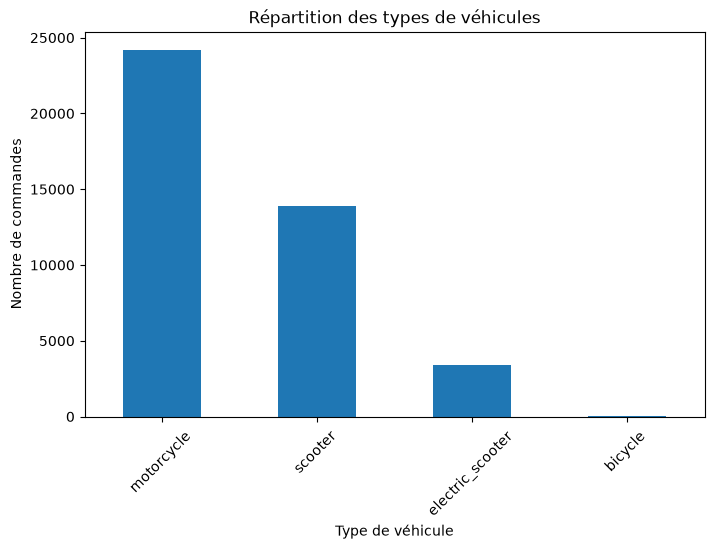

In [27]:
clean_df["Type_of_vehicle"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Type de véhicule")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des types de véhicules")
plt.xticks(rotation=45)
plt.show()

### 5.5 Analyse des valeurs aberrantes

Nous allons maintenant rechercher les valeurs aberrantes dans les variables numériques.

Une valeur aberrante est une observation qui est très éloignée de la majorité des autres valeurs.

Nous utiliserons des boxplots pour identifier visuellement ces valeurs.

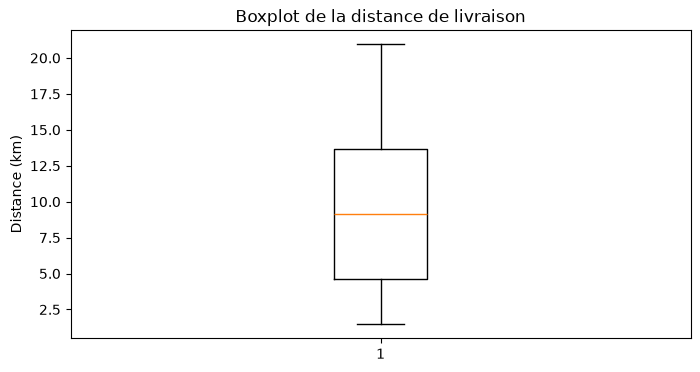

In [28]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["distance"])

plt.ylabel("Distance (km)")
plt.title("Boxplot de la distance de livraison")

plt.show()

In [29]:
clean_df["distance"].describe()

count    41522.000000
mean         9.704133
std          5.593935
min          1.463837
25%          4.648474
50%          9.177295
75%         13.659637
max         20.942906
Name: distance, dtype: float64

### 5.5.1 Analyse des valeurs aberrantes

Dans cette étape, nous allons rechercher les **valeurs aberrantes (outliers)** dans les variables numériques.

L'objectif est d'identifier les valeurs inhabituelles qui peuvent influencer l'analyse ou le futur modèle de machine learning.

Nous commencerons par analyser la variable `distance`.

In [30]:
Q1 = clean_df["distance"].quantile(0.25)
Q3 = clean_df["distance"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)

Q1 : 4.64847378122608
Q3 : 13.659636883890228
IQR : 9.011163102664147
Lower bound : -8.86827087277014
Upper bound : 27.17638153788645


In [31]:
outliers = clean_df[
    (clean_df["distance"] < lower_bound) |
    (clean_df["distance"] > upper_bound)
]

print("Nombre d'outliers :", len(outliers))


Nombre d'outliers : 0


### 5.5.2 Analyse des valeurs aberrantes du temps de livraison

Nous allons maintenant analyser les valeurs aberrantes de la variable cible `Time_taken(min)`.

L'objectif est d'identifier les temps de livraison qui sont très éloignés de la majorité des observations.

Pour cela, nous utiliserons un boxplot et la méthode de l'IQR afin de déterminer les limites statistiques des valeurs normales.

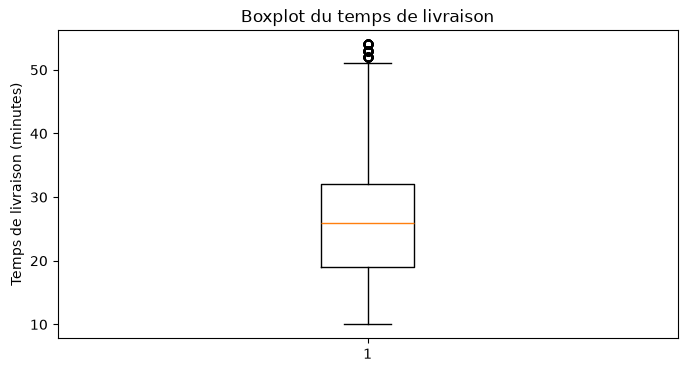

In [32]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["Time_taken(min)"])

plt.ylabel("Temps de livraison (minutes)")
plt.title("Boxplot du temps de livraison")

plt.show()

In [33]:
Q1 = clean_df["Time_taken(min)"].quantile(0.25)
Q3 = clean_df["Time_taken(min)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 


print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)

Q1 : 19.0
Q3 : 32.0
IQR : 13.0
Lower bound : -0.5
Upper bound : 51.5


In [34]:
outliers = clean_df[
    (clean_df["Time_taken(min)"] < lower_bound) |
    (clean_df["Time_taken(min)"] > upper_bound)
]

print("Nombre d'outliers :", len(outliers))
print(outliers.columns.tolist())


Nombre d'outliers : 243
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'multiple_deliveries', 'Time_taken(min)', 'distance', 'order_hour', 'pickup_hour']


### 5.5.3 Analyse des valeurs aberrantes de l'âge

Nous allons maintenant analyser les valeurs aberrantes de la variable `Delivery_person_Age`.

L'objectif est de vérifier s'il existe des âges qui sont statistiquement éloignés de la majorité des observations.

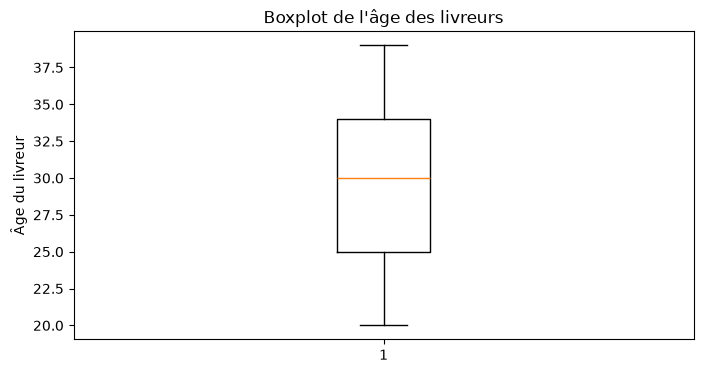

In [35]:

plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["Delivery_person_Age"])

plt.ylabel("Âge du livreur")
plt.title("Boxplot de l'âge des livreurs")

plt.show()

In [36]:
Q1 = clean_df["Delivery_person_Age"].quantile(0.25)
Q3 = clean_df["Delivery_person_Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["Delivery_person_Age"] < lower_bound) |
    (clean_df["Delivery_person_Age"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 25.0
Q3 : 34.0
IQR : 9.0
Lower bound : 11.5
Upper bound : 47.5
Nombre d'outliers : 0


### 5.5.5 Analyse des valeurs aberrantes de `multiple_deliveries`

Nous allons maintenant analyser la variable `multiple_deliveries` afin de vérifier la présence éventuelle de valeurs aberrantes.

Nous utiliserons un boxplot puis la méthode de l'IQR pour identifier les valeurs statistiquement inhabituelles.

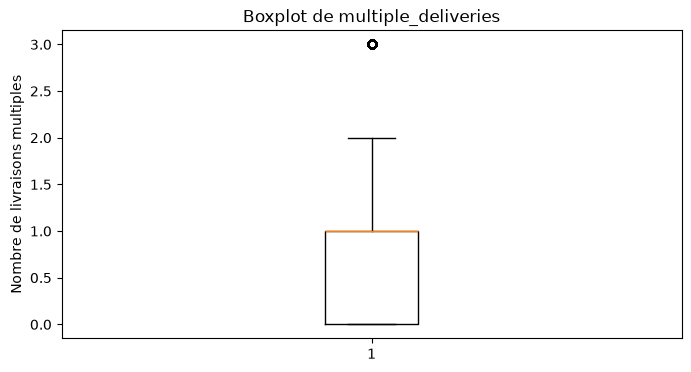

In [37]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["multiple_deliveries"])

plt.ylabel("Nombre de livraisons multiples")
plt.title("Boxplot de multiple_deliveries")

plt.show()

In [38]:
Q1 = clean_df["multiple_deliveries"].quantile(0.25)
Q3 = clean_df["multiple_deliveries"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["multiple_deliveries"] < lower_bound) |
    (clean_df["multiple_deliveries"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower bound : -1.5
Upper bound : 2.5
Nombre d'outliers : 323


#### Interprétation

La méthode de l'IQR identifie 323 valeurs aberrantes dans `multiple_deliveries`.

La borne supérieure est de 2,5. Ainsi, les observations ayant la valeur 3 sont considérées comme des outliers statistiques.

Cependant, la valeur 3 est une valeur valide présente dans le dataset et ne représente pas nécessairement une erreur.

Nous conservons donc ces observations afin de ne pas supprimer des informations potentiellement utiles pour la prédiction.

### 5.5.6 Analyse des valeurs aberrantes de `order_hour`

Nous allons maintenant analyser la variable `order_hour` afin de vérifier la présence éventuelle de valeurs aberrantes.

Cette variable représente l'heure à laquelle la commande a été passée. Nous utiliserons un boxplot et la méthode de l'IQR pour identifier les valeurs statistiquement inhabituelles.

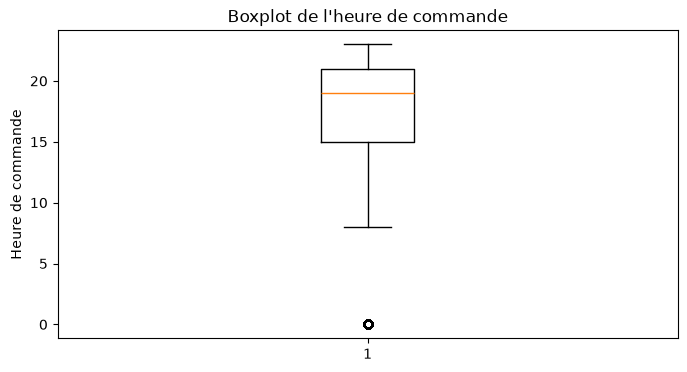

In [39]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["order_hour"])

plt.ylabel("Heure de commande")
plt.title("Boxplot de l'heure de commande")

plt.show()

In [40]:
Q1 = clean_df["order_hour"].quantile(0.25)
Q3 = clean_df["order_hour"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["order_hour"] < lower_bound) |
    (clean_df["order_hour"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 15.0
Q3 : 21.0
IQR : 6.0
Lower bound : 6.0
Upper bound : 30.0
Nombre d'outliers : 395


### 5.5.7 Analyse des valeurs aberrantes de `pickup_hour`

Nous allons enfin analyser la variable `pickup_hour` afin de vérifier la présence éventuelle de valeurs inhabituelles.

Cette variable représente l'heure à laquelle la commande a été récupérée par le livreur. Nous utiliserons un boxplot et la méthode de l'IQR.

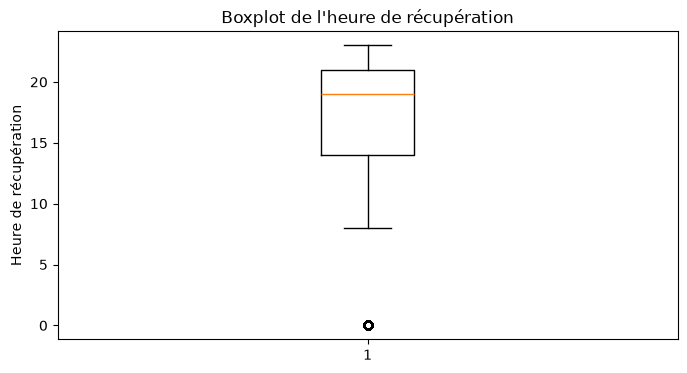

In [41]:
plt.figure(figsize=(8, 4))

plt.boxplot(clean_df["pickup_hour"])

plt.ylabel("Heure de récupération")
plt.title("Boxplot de l'heure de récupération")

plt.show()

In [42]:
Q1 = clean_df["pickup_hour"].quantile(0.25)
Q3 = clean_df["pickup_hour"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = clean_df[
    (clean_df["pickup_hour"] < lower_bound) |
    (clean_df["pickup_hour"] > upper_bound)
]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower bound :", lower_bound)
print("Upper bound :", upper_bound)
print("Nombre d'outliers :", len(outliers))

Q1 : 14.0
Q3 : 21.0
IQR : 7.0
Lower bound : 3.5
Upper bound : 31.5
Nombre d'outliers : 1196


#### Interprétation

La méthode de l'IQR identifie 1 196 valeurs comme aberrantes dans `pickup_hour`.

Cependant, `pickup_hour` représente une heure de la journée comprise entre 0 et 23. Les valeurs inférieures à 3,5 sont donc des heures valides et ne représentent pas nécessairement des erreurs.

Nous conservons donc toutes les observations de cette variable et ne supprimons aucune valeur.

### 5.5.8 Conclusion de l'analyse des valeurs aberrantes

L'analyse des valeurs aberrantes a permis d'identifier les observations inhabituelles dans les variables numériques.

Certaines valeurs ont été considérées comme des outliers par la méthode de l'IQR. Cependant, elles ne représentent pas forcément des erreurs, notamment pour les variables `multiple_deliveries`, `order_hour` et `pickup_hour`.

Après vérification, nous avons décidé de conserver ces observations afin de ne pas supprimer des informations potentiellement utiles pour la prédiction du temps de livraison.

In [43]:
clean_df.columns.tolist()

['Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Weatherconditions',
 'Road_traffic_density',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Time_taken(min)',
 'distance',
 'order_hour',
 'pickup_hour']

### 5.6.1 Relation entre la distance et le temps de livraison

Nous allons maintenant analyser la relation entre la distance de livraison et le temps de livraison.

L'objectif est de vérifier si la distance parcourue est liée au temps nécessaire pour effectuer une livraison.

Pour cela, nous utiliserons un **scatter plot**, adapté à l'analyse de la relation entre deux variables numériques.

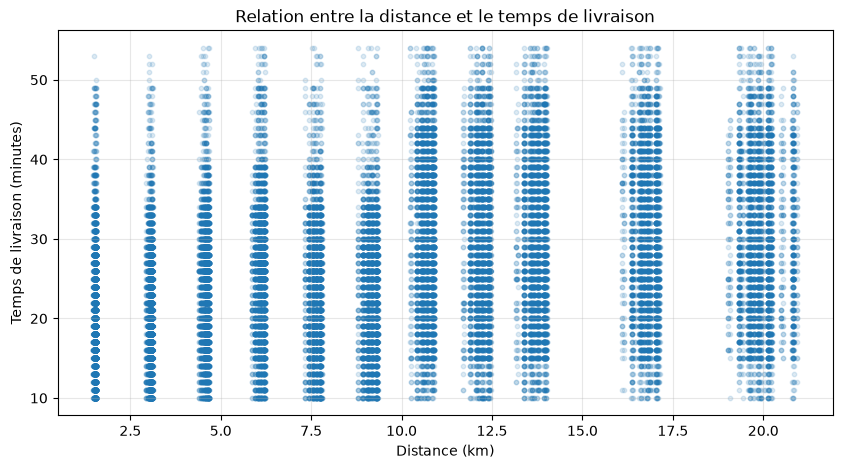

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    clean_df["distance"],
    clean_df["Time_taken(min)"],
    alpha=0.15,
    s=10
)

plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Relation entre la distance et le temps de livraison")

plt.grid(alpha=0.3)

plt.show()

In [67]:
clean_df["distance"].round(1).value_counts().head(15)

distance
1.5     3124
3.1     2129
4.6     1795
3.0     1508
7.6     1405
6.2     1272
9.3     1204
4.5     1192
6.1     1170
6.0     1148
12.4    1109
12.1    1066
10.6     970
10.7     928
7.7      923
Name: count, dtype: int64

In [68]:
clean_df.groupby(
    ["Restaurant_latitude", "Restaurant_longitude",
     "Delivery_location_latitude", "Delivery_location_longitude"]
).size().sort_values(ascending=False).head(10)

Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude
21.160522            72.771477             21.250522                   72.861477                      18
26.902940            75.793007             27.032940                   75.923007                      18
22.760072            75.892574             22.830072                   75.962574                      18
26.913483            75.803139             26.923483                   75.813139                      18
12.323994            76.626167             12.373994                   76.676167                      18
12.906229            77.596791             12.986229                   77.676791                      18
12.913041            77.683237             13.003041                   77.773237                      18
22.320000            73.170000             22.400000                   73.250000                      18
22.753839            75.897429             22.863838         

### 5.6.2 Relation entre l'âge, la note et le temps de livraison

Nous allons analyser la relation entre `Delivery_person_Age`, `Delivery_person_Ratings` et la variable cible `Time_taken(min)`.

L'objectif est de déterminer si ces variables peuvent apporter des informations utiles pour prédire le temps de livraison.

Nous utiliserons la corrélation ainsi que des graphiques de régression pour observer les relations entre ces variables.

In [77]:
clean_df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Time_taken(min)"
    ]
].corr()

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min)
Delivery_person_Age,1.000000,-0.113267,0.297630
Delivery_person_Ratings,-0.113267,1.000000,-0.340547
Time_taken(min),0.297630,-0.340547,1.000000


### 5.6.3 Relation entre le trafic et le temps de livraison

Nous allons analyser la relation entre la densité du trafic et le temps de livraison.

La variable `Road_traffic_density` est catégorielle, tandis que `Time_taken(min)` est numérique. Nous utiliserons donc un **boxplot** pour comparer la distribution des temps de livraison selon le niveau de trafic.

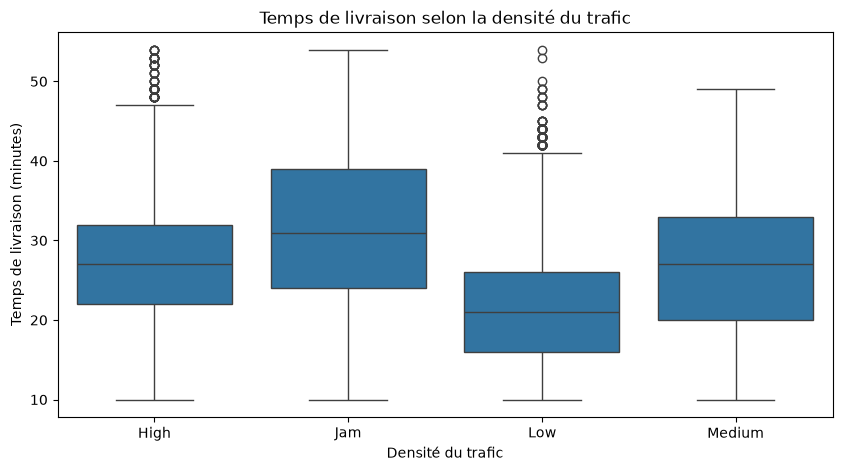

In [69]:


plt.figure(figsize=(10, 5))

sns.boxplot(
    data=clean_df,
    x="Road_traffic_density",
    y="Time_taken(min)"
)

plt.xlabel("Densité du trafic")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Temps de livraison selon la densité du trafic")

plt.show()

In [70]:
clean_df.groupby("Road_traffic_density")["Time_taken(min)"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median")

,count,mean,median,min,max
Road_traffic_density,,,,,
Low,14503,21.423223,21.0,10,54
High,4046,27.211567,27.0,10,54
Medium,10023,26.736406,27.0,10,49
Jam,12950,31.188571,31.0,10,54


In [71]:
def count_outliers(group):
    q1 = group["Time_taken(min)"].quantile(0.25)
    q3 = group["Time_taken(min)"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((group["Time_taken(min)"] < lower) |
            (group["Time_taken(min)"] > upper)).sum()

outliers_by_traffic = (
    clean_df
    .groupby("Road_traffic_density")
    .apply(count_outliers)
)

outliers_by_traffic

Road_traffic_density
High       84
Jam         0
Low       174
Medium      0
dtype: int64

### 5.6.4 Relation entre les conditions météorologiques et le temps de livraison

Nous allons analyser la relation entre les conditions météorologiques et le temps de livraison.

La variable `Weatherconditions` est catégorielle, tandis que `Time_taken(min)` est numérique. Nous utiliserons donc un **boxplot** afin de comparer la distribution des temps de livraison selon les différentes conditions météorologiques.

L'objectif est de vérifier si certaines conditions météorologiques sont associées à des temps de livraison plus élevés.

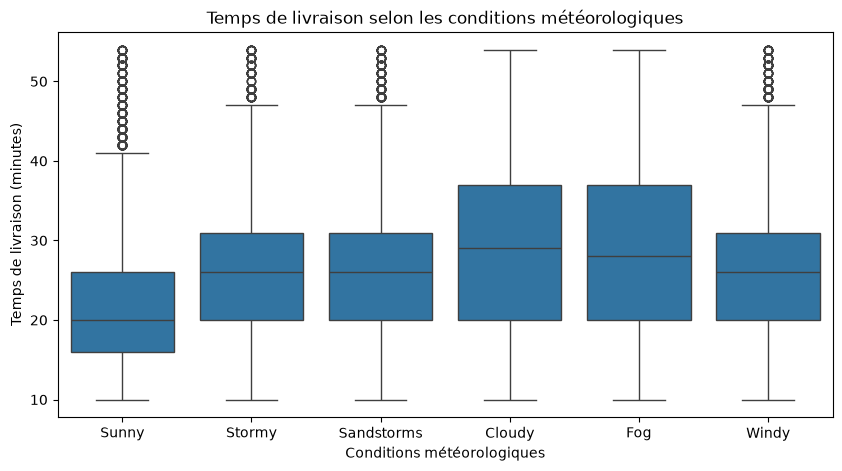

In [72]:


plt.figure(figsize=(10, 5))

sns.boxplot(
    data=clean_df,
    x="Weatherconditions",
    y="Time_taken(min)"
)

plt.xlabel("Conditions météorologiques")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Temps de livraison selon les conditions météorologiques")

plt.show()

In [73]:
clean_df.groupby("Weatherconditions")["Time_taken(min)"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median")

,count,mean,median,min,max
Weatherconditions,,,,,
Sunny,6682,21.895091,20.0,10,54
Stormy,6932,25.892095,26.0,10,54
Windy,6792,26.138840,26.0,10,54
Sandstorms,6853,25.877718,26.0,10,54
Fog,7382,28.844487,28.0,10,54
Cloudy,6881,28.931551,29.0,10,54


In [74]:
def count_outliers(group):
    q1 = group["Time_taken(min)"].quantile(0.25)
    q3 = group["Time_taken(min)"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (
        (group["Time_taken(min)"] < lower) |
        (group["Time_taken(min)"] > upper)
    ).sum()


outliers_by_weather = (
    clean_df
    .groupby("Weatherconditions")
    .apply(count_outliers)
)

outliers_by_weather

Weatherconditions
Cloudy          0
Fog             0
Sandstorms    124
Stormy        101
Sunny         273
Windy         128
dtype: int64

#### Interprétation des valeurs aberrantes

La méthode de l'IQR identifie **626 valeurs aberrantes** dans le temps de livraison selon les conditions météorologiques.

Les valeurs aberrantes sont principalement présentes dans les catégories `Sunny`, `Windy`, `Sandstorms` et `Stormy`. Aucune valeur aberrante n'est détectée pour `Cloudy` et `Fog`.

Cependant, ces observations ne représentent pas nécessairement des erreurs. Des temps de livraison élevés peuvent être liés à d'autres facteurs du dataset, comme la distance ou le trafic.

Nous conservons donc ces observations afin de ne pas supprimer des informations potentiellement utiles pour la prédiction.


### 5.6.5 Relation entre le type de véhicule et le temps de livraison

Nous allons analyser la relation entre le type de véhicule utilisé et le temps de livraison.

La variable `Type_of_vehicle` est catégorielle, tandis que `Time_taken(min)` est numérique. Nous utiliserons un **boxplot** afin de comparer la distribution des temps de livraison selon les différents types de véhicules.

L'objectif est de vérifier si le type de véhicule est associé à des différences dans le temps de livraison.

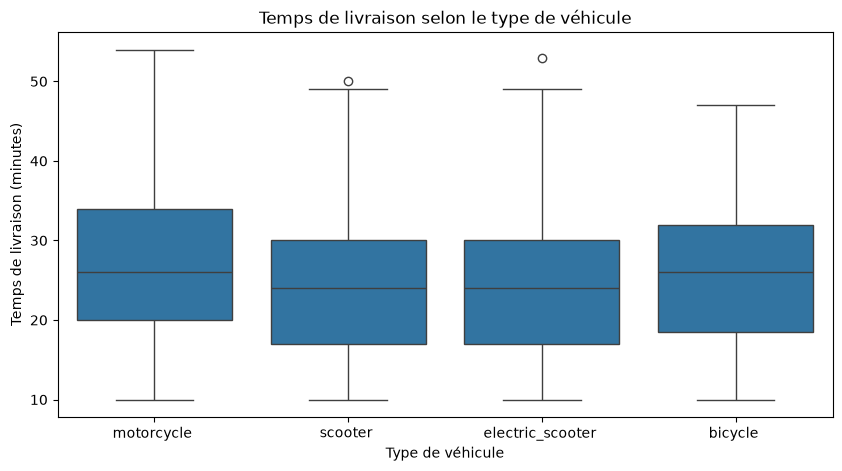

In [75]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=clean_df,
    x="Type_of_vehicle",
    y="Time_taken(min)"
)

plt.xlabel("Type de véhicule")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Temps de livraison selon le type de véhicule")

plt.show()

In [76]:
clean_df.groupby("Type_of_vehicle")["Time_taken(min)"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median")

,count,mean,median,min,max
Type_of_vehicle,,,,,
electric_scooter,3404,24.469154,24.0,10,53
scooter,13878,24.510448,24.0,10,50
bicycle,43,25.953488,26.0,10,47
motorcycle,24197,27.611067,26.0,10,54


In [77]:
def count_outliers(group):
    q1 = group["Time_taken(min)"].quantile(0.25)
    q3 = group["Time_taken(min)"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (
        (group["Time_taken(min)"] < lower) |
        (group["Time_taken(min)"] > upper)
    ).sum()


outliers_by_vehicle = (
    clean_df
    .groupby("Type_of_vehicle")
    .apply(count_outliers)
)

outliers_by_vehicle

Type_of_vehicle
bicycle              0
electric_scooter     1
motorcycle           0
scooter              1
dtype: int64

#### Interprétation des valeurs aberrantes

La méthode de l'IQR identifie seulement **2 valeurs aberrantes** dans les différentes catégories de véhicules : une pour `scooter` et une pour `electric_scooter`.

Ces observations représentent une très faible proportion du dataset et ne sont pas nécessairement des erreurs.

Nous conservons donc ces observations afin de préserver les informations disponibles pour la prédiction du temps de livraison.


### 5.6.6 Relation entre le nombre de livraisons et le temps de livraison

Nous allons analyser la relation entre le nombre de livraisons effectuées simultanément et le temps de livraison.

La variable `multiple_deliveries` contient un nombre discret de livraisons, tandis que `Time_taken(min)` est numérique.

Nous utiliserons un **boxplot** pour comparer la distribution des temps de livraison selon le nombre de livraisons.

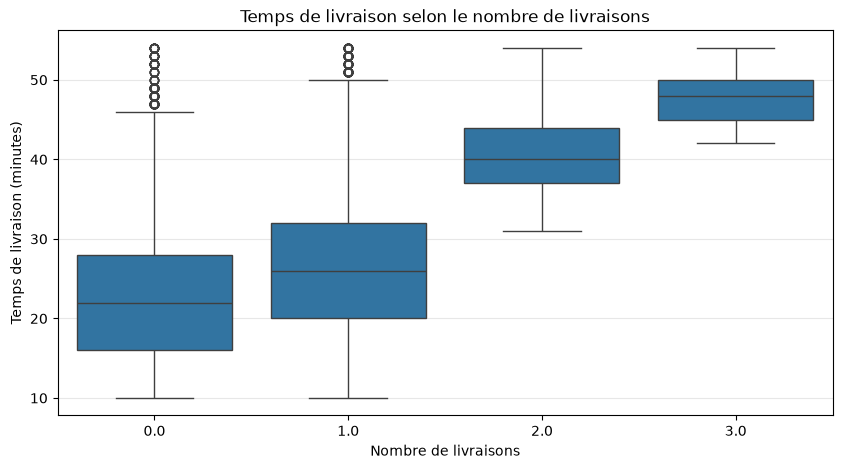

In [78]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=clean_df,
    x="multiple_deliveries",
    y="Time_taken(min)"
)

plt.xlabel("Nombre de livraisons")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Temps de livraison selon le nombre de livraisons")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [79]:
outliers_by_multiple = (
    clean_df
    .groupby("multiple_deliveries")
    .apply(count_outliers)
)

outliers_by_multiple

multiple_deliveries
0.0    164
1.0    145
2.0      0
3.0      0
dtype: int64

In [80]:
def outlier_details(group):
    values = group["Time_taken(min)"]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (values < lower) |
        (values > upper)
    ).sum()

    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_limit": lower,
        "Upper_limit": upper,
        "Outliers": outliers
    })


outlier_details_multiple = (
    clean_df
    .groupby("multiple_deliveries")
    .apply(outlier_details)
)

outlier_details_multiple

,Q1,Q3,IQR,Lower_limit,Upper_limit,Outliers
multiple_deliveries,,,,,,
0.0,16.0,28.0,12.0,-2.0,46.0,164.0
1.0,20.0,32.0,12.0,2.0,50.0,145.0
2.0,37.0,44.0,7.0,26.5,54.5,0.0
3.0,45.0,50.0,5.0,37.5,57.5,0.0


#### Interprétation des valeurs aberrantes

L'analyse avec la méthode de l'IQR identifie **309 valeurs aberrantes** dans le temps de livraison selon le nombre de livraisons.

Les catégories `0` et `1` présentent respectivement **164** et **145 valeurs aberrantes**, tandis que les catégories `2` et `3` ne présentent aucune valeur aberrante selon cette méthode.

Ces valeurs ne représentent pas nécessairement des erreurs. Elles peuvent correspondre à des situations réelles de livraison avec des temps plus élevés ou plus faibles que la majorité des observations.

Nous décidons donc de **conserver ces observations** afin de ne pas supprimer des informations potentiellement utiles pour la prédiction.


### 5.6.7 Relation entre l'âge du livreur et le temps de livraison

Nous allons analyser la relation entre l'âge du livreur et le temps de livraison.

Les deux variables sont numériques. Nous utiliserons donc un **scatter plot** afin d'observer visuellement leur relation.

Nous vérifierons également les valeurs aberrantes du temps de livraison pour chaque âge.

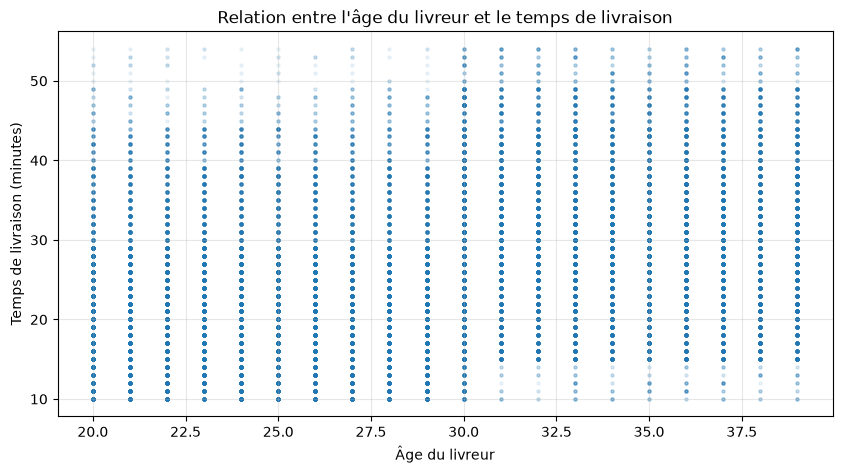

In [88]:
plt.figure(figsize=(10, 5))

plt.scatter(
    clean_df["Delivery_person_Age"],
    clean_df["Time_taken(min)"],
    alpha=0.08,
    s=5
)

plt.xlabel("Âge du livreur")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Relation entre l'âge du livreur et le temps de livraison")
plt.grid(alpha=0.3)

plt.show()

### 5.6.9 Relation entre la note du livreur et le temps de livraison

Nous allons analyser la relation entre la note du livreur et le temps de livraison.

Les deux variables sont numériques :
- `Delivery_person_Ratings` représente la note du livreur.
- `Time_taken(min)` représente le temps nécessaire pour effectuer la livraison.

Nous utiliserons un **scatter plot** pour observer la relation entre ces deux variables et nous calculerons le coefficient de corrélation afin de mesurer la force et la direction de cette relation.

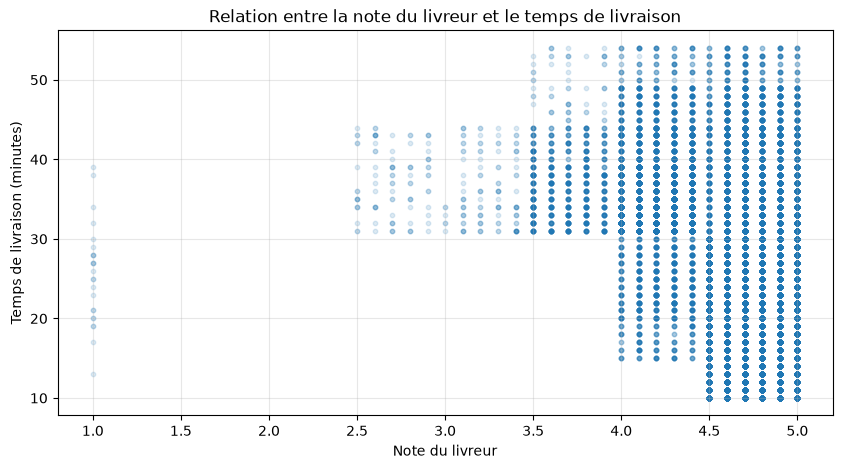

In [90]:
plt.figure(figsize=(10, 5))

plt.scatter(
    clean_df["Delivery_person_Ratings"],
    clean_df["Time_taken(min)"],
    alpha=0.15,
    s=10
)

plt.xlabel("Note du livreur")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Relation entre la note du livreur et le temps de livraison")
plt.grid(alpha=0.3)

plt.show()

In [91]:
clean_df[
    ["Delivery_person_Ratings", "Time_taken(min)"]
].corr()

,Delivery_person_Ratings,Time_taken(min)
Delivery_person_Ratings,1.000000,-0.340547
Time_taken(min),-0.340547,1.000000


#### Interprétation

Le coefficient de corrélation entre la note du livreur et le temps de livraison est de **-0,340547**.

Cette valeur indique une **corrélation négative faible à modérée**. Dans notre dataset, les livreurs ayant une note plus élevée sont généralement associés à des temps de livraison légèrement plus faibles.

Cependant, cette corrélation ne signifie pas que la note du livreur cause directement une réduction du temps de livraison. D'autres facteurs peuvent également influencer le temps de livraison.

Nous conservons donc `Delivery_person_Ratings` comme **variable potentiellement utile pour la modélisation**.


### 5.6.10 Relation entre l'heure de commande et le temps de livraison

Nous allons analyser la relation entre l'heure à laquelle la commande est passée et le temps de livraison.

Les deux variables sont numériques :

* `order_hour` représente l'heure de la commande.
* `Time_taken(min)` représente le temps de livraison.

Nous utiliserons un **scatter plot** afin d'observer s'il existe une relation entre l'heure de commande et le temps de livraison.


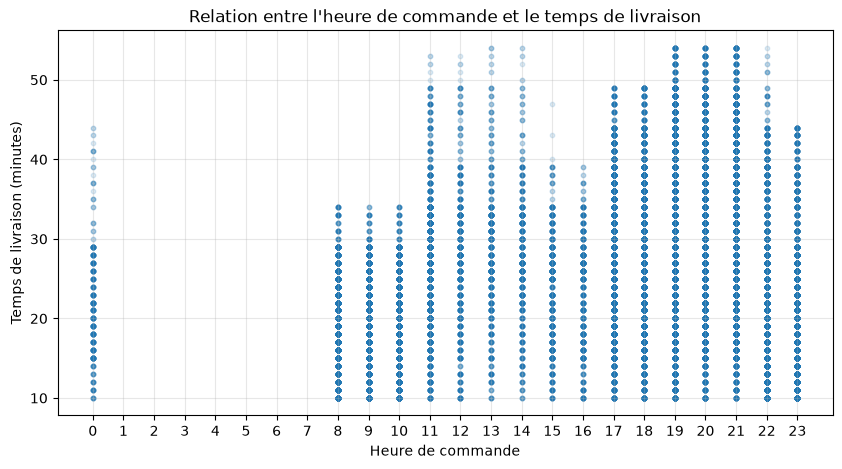

In [93]:
plt.figure(figsize=(10, 5))

plt.scatter(
    clean_df["order_hour"],
    clean_df["Time_taken(min)"],
    alpha=0.15,
    s=10
)

plt.xlabel("Heure de commande")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Relation entre l'heure de commande et le temps de livraison")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [94]:
clean_df[
    ["order_hour", "Time_taken(min)"]
].corr()

,order_hour,Time_taken(min)
order_hour,1.000000,0.182024
Time_taken(min),0.182024,1.000000


#### Interprétation

Le scatter plot montre que le temps de livraison varie selon l'heure de commande.

Les temps de livraison les plus élevés apparaissent principalement pendant les périodes de **midi (11h–14h)** et du **soir (19h–22h)**, avec des valeurs pouvant atteindre environ **55 minutes**. À l'inverse, les périodes du matin et certaines heures de l'après-midi présentent généralement des temps de livraison plus faibles.

Les commandes sont principalement réalisées entre **8h et minuit**, avec très peu ou aucune observation entre **1h et 7h**.

Ces observations montrent que `order_hour` peut être une **variable potentiellement utile pour la prédiction du temps de livraison**.


### 5.6.11 Relation entre l'heure de prise en charge et le temps de livraison

Nous allons analyser la relation entre l'heure de prise en charge de la commande et le temps de livraison.

Les deux variables sont numériques :

* `pickup_hour` représente l'heure à laquelle la commande est prise en charge.
* `Time_taken(min)` représente le temps de livraison.

Nous utiliserons un **scatter plot** afin d'observer s'il existe une relation entre ces deux variables.


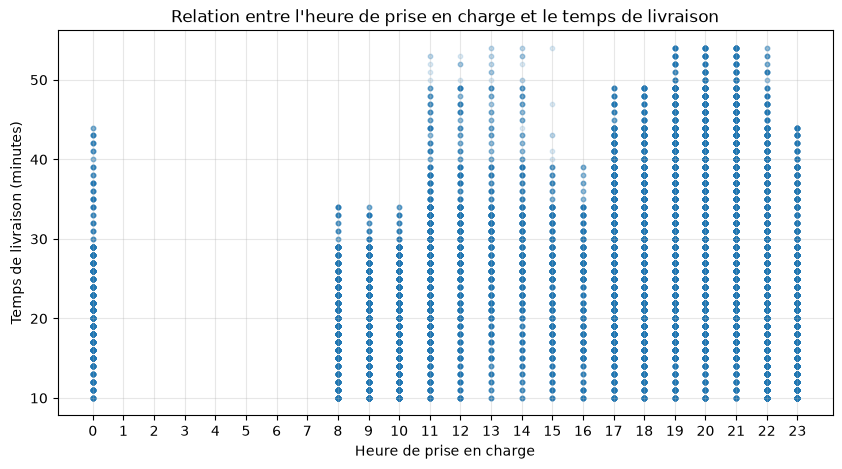

In [95]:
plt.figure(figsize=(10, 5))

plt.scatter(
    clean_df["pickup_hour"],
    clean_df["Time_taken(min)"],
    alpha=0.15,
    s=10
)

plt.xlabel("Heure de prise en charge")
plt.ylabel("Temps de livraison (minutes)")
plt.title("Relation entre l'heure de prise en charge et le temps de livraison")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

In [96]:
clean_df[
    ["pickup_hour", "Time_taken(min)"]
].corr()

,pickup_hour,Time_taken(min)
pickup_hour,1.000000,0.204032
Time_taken(min),0.204032,1.000000


### 5.6.12 Matrice de corrélation

Nous allons utiliser une **heatmap** pour visualiser les corrélations entre toutes les variables numériques du dataset.

Cette représentation permet de comparer rapidement les relations entre les variables et d'identifier celles qui présentent une relation avec notre variable cible `Time_taken(min)`.


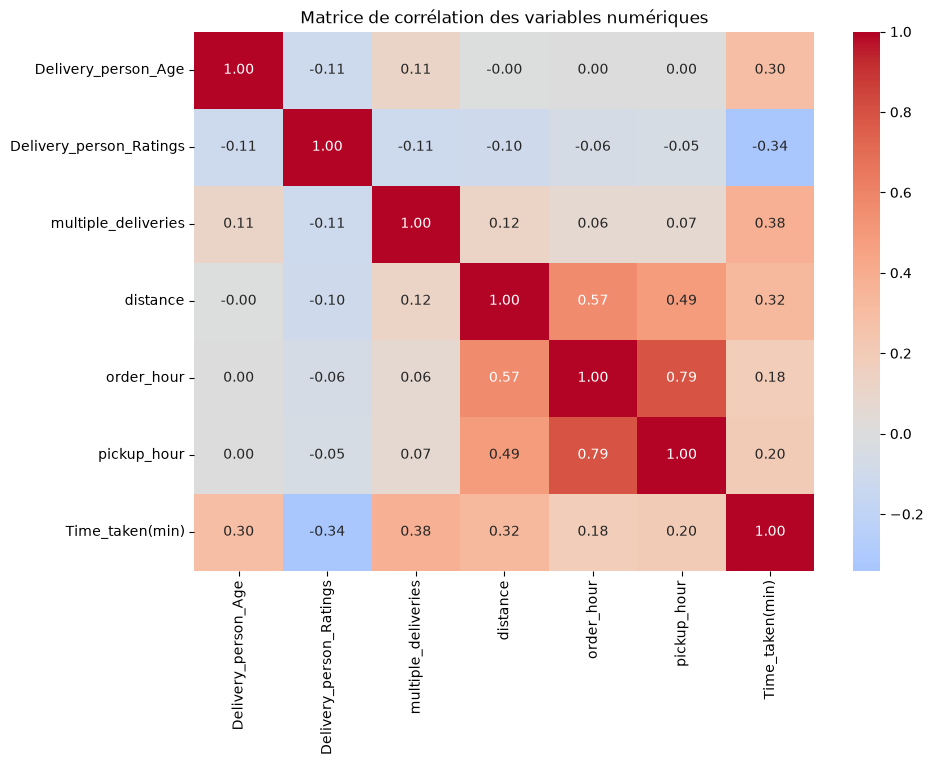

In [97]:


numerical_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance",
    "order_hour",
    "pickup_hour",
    "Time_taken(min)"
]

corr_matrix = clean_df[numerical_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

#### Interprétation

La matrice de corrélation permet d'avoir une vue globale des relations entre les variables numériques.

Concernant la variable cible `Time_taken(min)`, les relations les plus importantes sont observées avec `multiple_deliveries` (**+0,38**), `Delivery_person_Ratings` (**-0,34**) et `distance` (**+0,32**).

Les variables `Delivery_person_Age` (**+0,30**), `pickup_hour` (**+0,20**) et `order_hour` (**+0,18**) présentent des relations plus faibles avec le temps de livraison.

On observe également une forte corrélation entre `order_hour` et `pickup_hour` (**+0,79**), ce qui est cohérent puisque la prise en charge intervient généralement peu après la commande.

La corrélation permet d'identifier des relations entre les variables, mais elle ne permet pas à elle seule de déterminer l'importance réelle d'une variable pour le modèle. Nous conserverons donc les variables pertinentes pour la suite et leur utilité sera évaluée lors de la modélisation.


### -------------------------------------

### 5.7 Conclusion de l'analyse exploratoire

L'analyse exploratoire nous a permis de mieux comprendre la structure du dataset et les principaux facteurs associés au temps de livraison.

Les principales observations sont :

* `multiple_deliveries` présente une relation positive avec le temps de livraison.
* `distance` est également associée à une augmentation du temps de livraison.
* `Delivery_person_Ratings` présente une relation négative avec le temps de livraison.
* `Delivery_person_Age` présente une relation positive mais relativement faible.
* `order_hour` et `pickup_hour` présentent des relations faibles avec le temps de livraison, mais les graphiques montrent des variations selon les périodes de la journée.
* `Road_traffic_density` montre des différences importantes entre les catégories, notamment entre `Low` et `Jam`.
* `Weatherconditions` est également associée à des différences dans les temps de livraison.
* `Type_of_vehicle` présente certaines différences entre les catégories, mais la catégorie `bicycle` contient très peu d'observations.

L'analyse des valeurs aberrantes a montré que certaines observations sont considérées comme des outliers par la méthode de l'IQR. Cependant, elles ne représentent pas nécessairement des erreurs et ont donc été conservées lorsqu'elles semblaient plausibles.

Enfin, la matrice de corrélation a permis d'identifier les principales relations entre les variables numériques. Cependant, la corrélation seule ne permet pas de déterminer quelles variables seront les plus utiles pour le modèle.

Le dataset est maintenant mieux compris et peut passer à l'étape suivante : **la préparation des données et le feature engineering pour la modélisation**.
